# Exploratory Data Analysis (EDA)

## Telco Customer Churn Analysis

### Project Background

Customer churn merupakan salah satu permasalahan utama dalam industri telekomunikasi. Ketika pelanggan berhenti menggunakan layanan, perusahaan tidak hanya kehilangan pelanggan, tetapi juga menghadapi penurunan pendapatan serta biaya tambahan untuk memperoleh pelanggan baru. Oleh karena itu, memahami pola perilaku pelanggan yang berisiko churn menjadi sangat penting untuk membantu perusahaan merancang **strategi retensi yang lebih efektif**.

Notebook ini berfokus pada tahap **Exploratory Data Analysis (EDA)** untuk memahami karakteristik pelanggan serta mengidentifikasi faktor-faktor yang berkaitan dengan churn.

---

### Dataset Overview

Dataset yang digunakan adalah **Telco Customer Churn Dataset** yang berisi informasi mengenai **7.043 pelanggan** dengan **21 fitur** yang mencakup:

* **Customer Demographics**
  Gender, Senior Citizen, Partner, Dependents

* **Account Information**
  Tenure, Contract Type, Payment Method, Monthly Charges, Total Charges

* **Service Usage**
  Internet Service, Online Security, Streaming TV, Streaming Movies, dan layanan lainnya

* **Target Variable**

  * **Churn** → menunjukkan apakah pelanggan berhenti berlangganan atau tidak

Dataset yang digunakan pada tahap ini merupakan hasil dari proses **data cleaning** yang dilakukan pada tahap sebelumnya.

---

### Objectives

Tujuan utama dari tahap EDA ini adalah:

1. Memahami struktur dan kualitas dataset
2. Menganalisis distribusi variabel pelanggan
3. Mengidentifikasi faktor yang berkaitan dengan churn
4. Menemukan pola perilaku pelanggan yang berisiko churn
5. Mengestimasi potensi **revenue loss akibat churn**

---

### Analysis Scope

Analisis pada notebook ini mencakup beberapa tahapan utama:

* **Data Overview**
  Memeriksa dimensi data, tipe variabel, missing values, dan duplikasi data.

* **Univariate Analysis**
  Menganalisis distribusi variabel seperti gender, tenure, monthly charges, contract type, dan churn.

* **Bivariate Analysis**
  Mengidentifikasi hubungan antara churn dan variabel penting seperti contract type, payment method, internet service, dan senior citizen.

* **Correlation Analysis**
  Menggunakan correlation matrix untuk melihat hubungan antar variabel numerik.

* **Revenue Impact Analysis**
  Menghitung potensi kehilangan revenue akibat churn dan mengidentifikasi segmen pelanggan yang paling berkontribusi terhadap revenue loss.

---

### Expected Insights

Melalui analisis ini diharapkan dapat diperoleh insight mengenai:

* karakteristik pelanggan yang paling berisiko churn
* layanan atau kontrak yang berkaitan dengan churn tinggi
* segmen pelanggan yang perlu menjadi fokus strategi retensi
* potensi dampak churn terhadap revenue perusahaan

# Data Overview

In [1]:
# ============ Load Libraries dan Dataset =============

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Membaca file CSV hasil cleaning dari folder processed
df = pd.read_csv("../data/processed/Telco_Customer_Churn_Cleaned.csv")

In [2]:
# =============== Melihat Dimensi Dataset ===============

df.shape

(7043, 21)

In [3]:
# =============== Melihat Informasi Dataset ===============

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   bool   
 3   Partner           7043 non-null   bool   
 4   Dependents        7043 non-null   bool   
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   bool   
 7   MultipleLines     7043 non-null   bool   
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   bool   
 10  OnlineBackup      7043 non-null   bool   
 11  DeviceProtection  7043 non-null   bool   
 12  TechSupport       7043 non-null   bool   
 13  StreamingTV       7043 non-null   bool   
 14  StreamingMovies   7043 non-null   bool   
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   bool   
 17  Paymen

In [4]:
# =============== Mengecek Missing Values ===============

placeholders = ["", " ", "NA", "N/A", "null", "missing", "?"]

def custom_missing(series):
    return series.isna() | series.astype(str).str.strip().isin(placeholders)

# Hitung missing values versi custom
print(df.apply(lambda col: custom_missing(col).sum()))

# Missing values versi default pandas
print(df.isna().sum()[df.isna().sum() > 0])

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
Series([], dtype: int64)


In [5]:
# =============== Melihat Missing Values ===============

df.isna().sum()[df.isna().sum() > 0]

Series([], dtype: int64)

In [6]:
# ============= Melihat Duplikasi data =============

df['customerID'].duplicated().sum()

np.int64(0)

**Insight**

1. Dataset terdiri dari 7043 pelanggan dengan 21 fitur.
2. Tidak ditemukan missing values, baik secara eksplisit (NaN) maupun berdasarkan pengecekan placeholder umum seperti " ", "NA", "null", dan sejenisnya.
3. Tidak ditemukan duplikasi customerID, sehingga setiap baris merepresentasikan pelanggan unik.
4. Dataset siap untuk tahap Exploratory Data Analysis (EDA) lanjutan dan Feature Engineering.

# Univariate Analysis

In [7]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-vhveg,female,False,True,False,1,False,False,dsl,False,...,False,False,False,False,month-to-month,True,electronic check,29.85,29.85,False
1,5575-gnvde,male,False,False,False,34,True,False,dsl,True,...,True,False,False,False,one year,False,mailed check,56.95,1889.50,False
2,3668-qpybk,male,False,False,False,2,True,False,dsl,True,...,False,False,False,False,month-to-month,True,mailed check,53.85,108.15,True
3,7795-cfocw,male,False,False,False,45,False,False,dsl,True,...,True,True,False,False,one year,False,bank transfer (automatic),42.30,1840.75,False
4,9237-hqitu,female,False,False,False,2,True,False,fiber optic,False,...,False,False,False,False,month-to-month,True,electronic check,70.70,151.65,True


In [8]:
# ==================== Set Visual Style =====================

# Mengatur style visual agar grafik lebih mudah dibaca
sns.set(style="whitegrid")

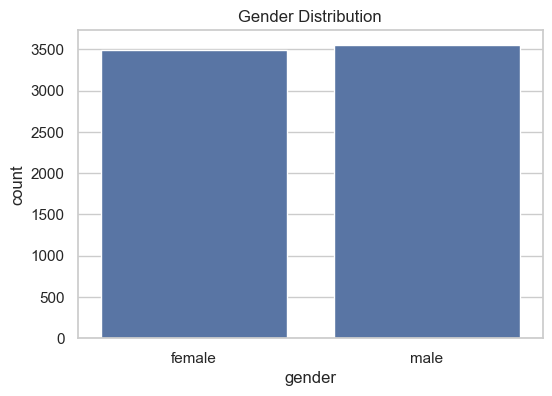

In [9]:
# =============== Distribusi Gender ===============
# Melihat apakah terdapat ketimpangan gender dalam pelanggan

plt.figure(figsize=(6,4))
sns.countplot(x="gender", data=df)
plt.title("Gender Distribution")
plt.show()

**Insight**

Komposisi pelanggan berdasarkan gender relatif seimbang. Oleh karena itu, distribusi ini saja belum cukup untuk menyimpulkan pengaruh gender terhadap churn dan perlu dianalisis lebih lanjut bersama variabel churn.

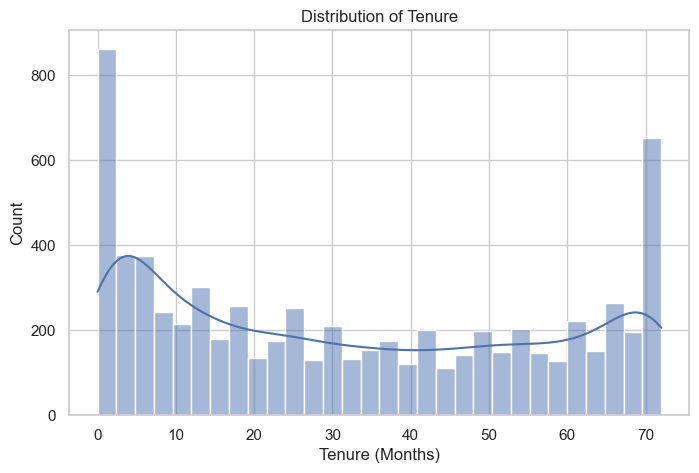

In [10]:
# ================= Distribusi tenure ==================
# Melihat lama pelanggan bertahan (dalam bulan)
# - Apakah mayoritas pelanggan masih baru?
# - Apakah ada indikasi churn tinggi pada tenure rendah?

plt.figure(figsize=(8,5))
sns.histplot(df["tenure"], bins=30, kde=True)
plt.title("Distribution of Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Count")
plt.show()


**Insight**

Distribusi tenure menunjukkan dua kelompok dominan, yaitu pelanggan sangat baru dan pelanggan sangat lama. Banyak pelanggan berhenti pada bulan-bulan awal, mengindikasikan risiko churn tinggi pada tenure rendah. Sebaliknya, pelanggan dengan tenure panjang cenderung lebih stabil dan loyal.

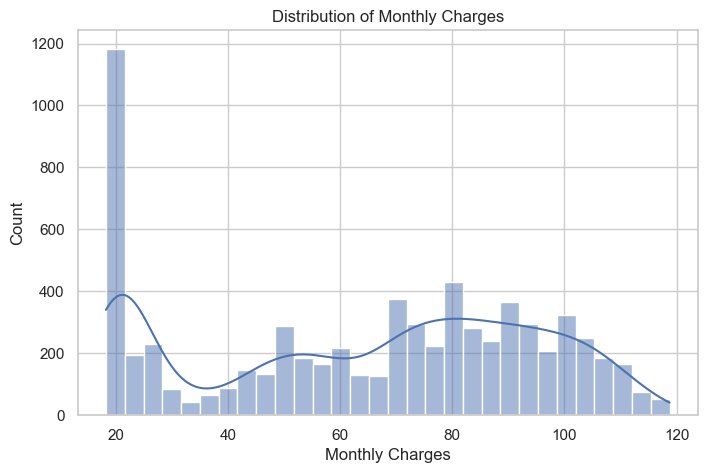

In [11]:
# ================ Distribusi MonthlyCharges ===================
# Melihat sebaran biaya bulanan pelanggan
# - Apakah pelanggan lebih banyak di harga rendah atau tinggi?
# - Apakah ada indikasi biaya tinggi berhubungan dengan churn?

plt.figure(figsize=(8,5))
sns.histplot(df["MonthlyCharges"], bins=30, kde=True)
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Count")
plt.show()

**Insight**

Distribusi Monthly Charges menunjukkan konsentrasi pelanggan pada biaya rendah, dengan kelompok lain tersebar pada biaya menengah hingga tinggi. Pola ini mengindikasikan adanya beberapa segmen harga pelanggan yang berbeda.

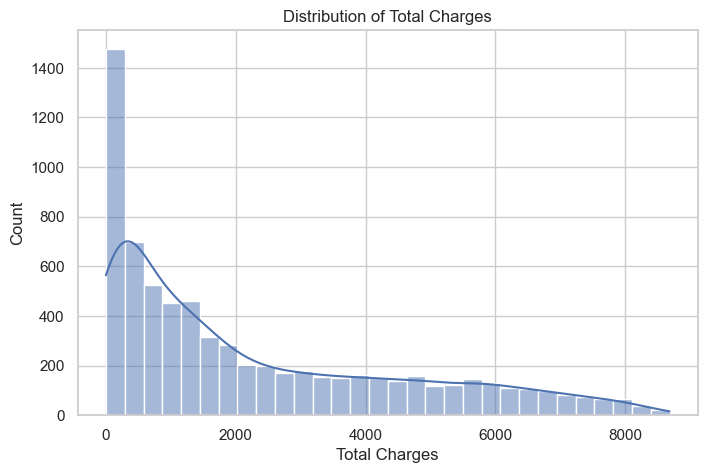

In [12]:
# ================= Distribusi TotalCharges ===================
# Melihat total pengeluaran pelanggan selama menjadi customer.
# - Pelanggan dengan total charges tinggi biasanya pelanggan lama.
# - Bisa menjadi indikator Customer Lifetime Value (CLV).

plt.figure(figsize=(8,5))
sns.histplot(df["TotalCharges"], bins=30, kde=True)
plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Count")
plt.show()

**Insight**

Distribusi Total Charges menunjukkan sebagian besar pelanggan memiliki pengeluaran rendah. Nilai total charges menurun secara bertahap seiring naiknya pengeluaran, sehingga hanya sebagian kecil pelanggan yang mencapai nilai tinggi. Pola ini mengindikasikan bahwa pelanggan dengan Total Charges tinggi kemungkinan memiliki tenure lebih panjang dan berkontribusi lebih besar terhadap Customer Lifetime Value (CLV).

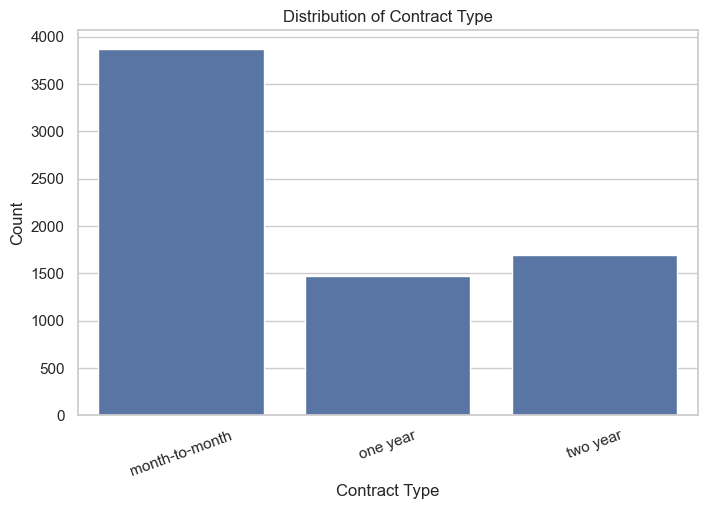

In [13]:
# =================== Distribusi Contract Type ===================
# Melihat jenis kontrak pelanggan (Monthly, One year, Two year).
# - Kontrak bulanan biasanya memiliki risiko churn lebih tinggi.
# - Kontrak jangka panjang cenderung lebih stabil.

plt.figure(figsize=(8,5))
sns.countplot(x="Contract", data=df)
plt.title("Distribution of Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()

**Insight**

Mayoritas pelanggan menggunakan kontrak month-to-month, jauh lebih tinggi dibandingkan kontrak one year dan two year. Pola ini mengindikasikan potensi churn yang lebih besar, karena pelanggan dengan kontrak bulanan memiliki fleksibilitas lebih tinggi untuk berhenti berlangganan kapan saja. Temuan ini menyarankan bahwa strategi retensi sebaiknya difokuskan pada pelanggan month-to-month, misalnya melalui program insentif untuk mendorong migrasi ke kontrak jangka panjang.

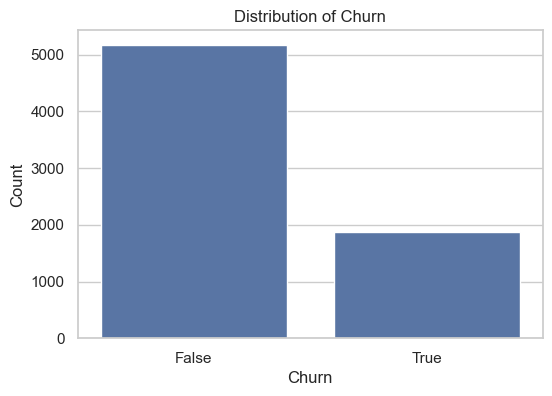

,Churn,Percentage
0,False,73.46
1,True,26.54


In [ ]:
# ====================== Distribusi Churn ======================
#  Mengevaluasi distribusi target variable (Churn).
# - Mengetahui baseline churn rate perusahaan.
# - Menjadi referensi evaluasi model.
# - Jika terjadi class imbalance, akan diuji apakah teknik penanganan imbalance benar-benar meningkatkan performa model.

plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Distribution of Churn")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

# ===================== Persentase Churn =====================
churn_pct = df["Churn"].value_counts(normalize=True) * 100
churn_pct = churn_pct.reset_index(name="Percentage").round(2)
churn_pct

**Insight**

Distribusi variabel target menunjukkan bahwa sebagian besar pelanggan tidak melakukan churn (0), dengan proporsi sekitar 73.46%, sementara pelanggan yang melakukan churn (1) sebesar 26.54%. Proporsi churn yang mencapai sekitar seperempat dari total pelanggan menunjukkan adanya risiko kehilangan pelanggan yang perlu ditangani melalui strategi retensi. Selain itu, ketidakseimbangan kelas perlu diperhatikan dalam pemodelan agar model tetap mampu mengidentifikasi pelanggan berisiko churn secara akurat.

# Bivariate Analysis

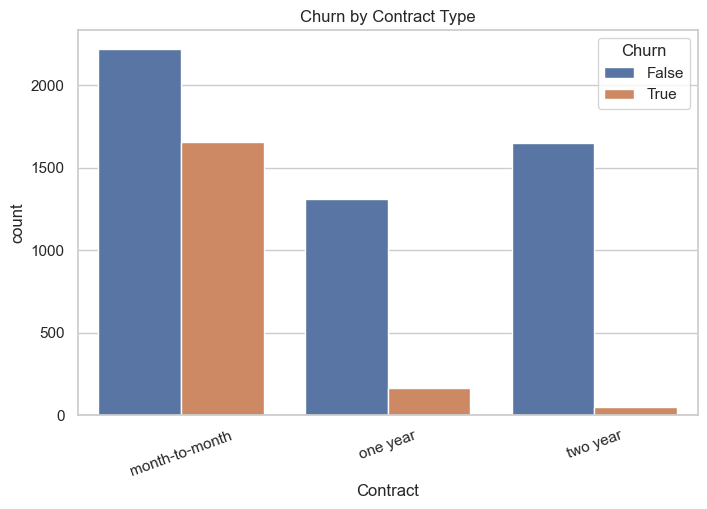

,No Churn (%),Churn (%)
Contract,,
month-to-month,57.29,42.71
one year,88.73,11.27
two year,97.17,2.83


In [15]:
# ==================== Churn vs Contract ====================
# - Apakah tipe kontrak mempengaruhi kemungkinan churn?

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn by Contract Type")
plt.xticks(rotation=20)
plt.show()

# Crosstab persentase churn per jenis kontrak
contract_churn =pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
contract_churn.columns = ["No Churn (%)", "Churn (%)"]
contract_churn = contract_churn.sort_values(by="Churn (%)", ascending=False).round(2)
contract_churn

**Insight**

Pelanggan dengan kontrak month-to-month memiliki jumlah churn paling tinggi (42.71%) dibandingkan tipe kontrak lainnya. Sebaliknya, pelanggan dengan kontrak one year dan terutama two year menunjukkan tingkat churn yang jauh lebih rendah. Hal ini menunjukkan bahwa semakin panjang durasi kontrak, semakin kecil kemungkinan pelanggan untuk churn, sehingga mendorong pelanggan beralih ke kontrak jangka panjang dapat menjadi strategi efektif untuk meningkatkan retensi.

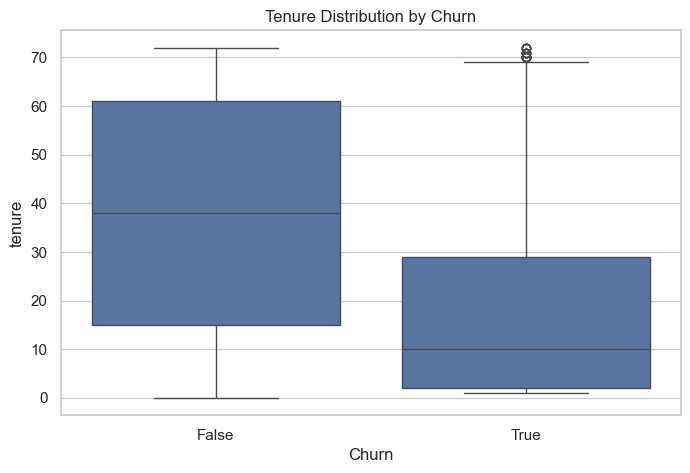

,Churn,tenure
0,False,38.0
1,True,10.0


In [16]:
# =================== Churn vs tenure ====================
# - Apakah pelanggan yang lebih baru cenderung lebih mudah churn?

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure Distribution by Churn")
plt.show()

# Hitung median tenure per kelompok churn
median_tenure_by_churn = (
    df.groupby("Churn")["tenure"]
      .median()
      .sort_values(ascending=False)
      .reset_index()
)

median_tenure_by_churn

**Insight**

Pelanggan yang melakukan churn cenderung memiliki tenure lebih pendek dibandingkan pelanggan yang tetap bertahan. Median tenure pelanggan churn hanya sekitar 10 bulan, sedangkan pelanggan non-churn mencapai 38 bulan. Hal ini menunjukkan bahwa risiko churn paling tinggi terjadi pada fase awal masa berlangganan, sehingga periode awal penggunaan layanan menjadi fase kritis untuk mempertahankan pelanggan.

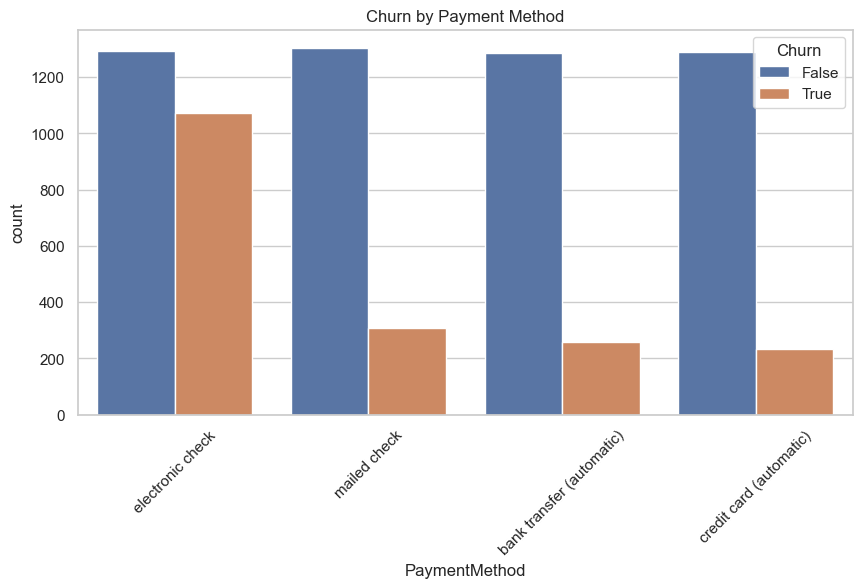

,No Churn (%),Churn (%)
PaymentMethod,,
electronic check,54.71,45.29
mailed check,80.89,19.11
bank transfer (automatic),83.29,16.71
credit card (automatic),84.76,15.24


In [17]:
# ================= Churn vs PaymentMethod =================
# - Apakah metode pembayaran tertentu memiliki risiko churn lebih tinggi?

plt.figure(figsize=(10,5))
sns.countplot(data=df, x="PaymentMethod", hue="Churn")
plt.title("Churn by Payment Method")
plt.xticks(rotation=45)
plt.show()

# Crosstab persentase churn per metode pembayaran
payment_churn = pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100
payment_churn.columns = ["No Churn (%)", "Churn (%)"]
payment_churn = payment_churn.sort_values(by="Churn (%)", ascending=False).round(2)
payment_churn

**Insight**

Metode pembayaran electronic check memiliki tingkat churn paling tinggi, dengan sekitar 45.29% pelanggan melakukan churn, jauh lebih besar dibandingkan metode lainnya. Sebaliknya, metode pembayaran automatic payment seperti bank transfer dan credit card menunjukkan tingkat churn yang jauh lebih rendah (sekitar 15–17%). Hal ini menunjukkan bahwa pelanggan yang menggunakan pembayaran otomatis cenderung lebih stabil, sehingga mendorong penggunaan automatic payment dapat menjadi strategi yang efektif untuk mengurangi churn. 

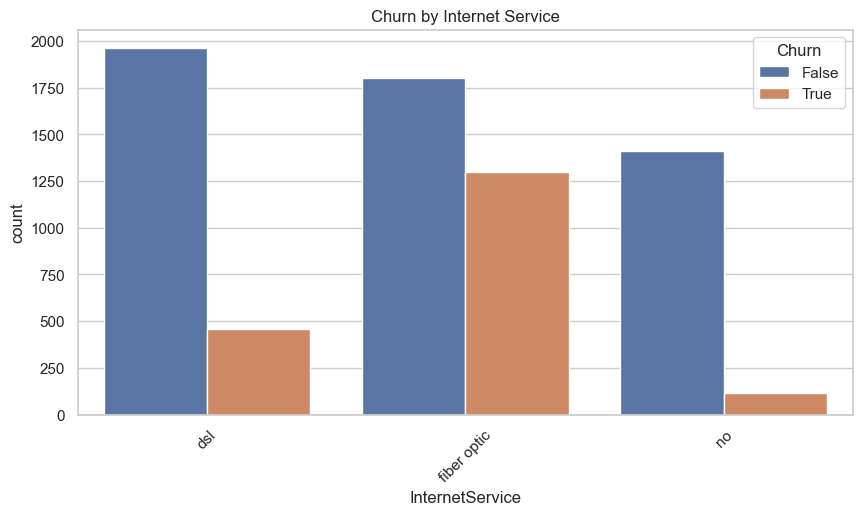

,No Churn (%),Churn (%)
InternetService,,
fiber optic,58.11,41.89
dsl,81.04,18.96
no,92.60,7.40


In [18]:
# ================== Churn vs InternetService ==================
# - Apakah jenis layanan internet mempengaruhi churn?

plt.figure(figsize=(10,5))
sns.countplot(data=df, x="InternetService", hue="Churn")
plt.title("Churn by Internet Service")
plt.xticks(rotation=45)
plt.show()

# Crosstab persentase churn per jenis layanan internet
internet_churn = pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100
internet_churn.columns = ["No Churn (%)", "Churn (%)"]
internet_churn = internet_churn.sort_values(by="Churn (%)", ascending=False).round(2)
internet_churn

**Insight**

Pelanggan yang menggunakan fiber optic memiliki tingkat churn tertinggi yaitu sekitar 41.89%, jauh lebih tinggi dibandingkan pelanggan DSL dengan churn sekitar 18.96%. Hal ini mengindikasikan bahwa segmen pelanggan ini mungkin lebih sensitif terhadap kualitas layanan atau harga, sehingga memerlukan perhatian khusus dalam strategi retensi.

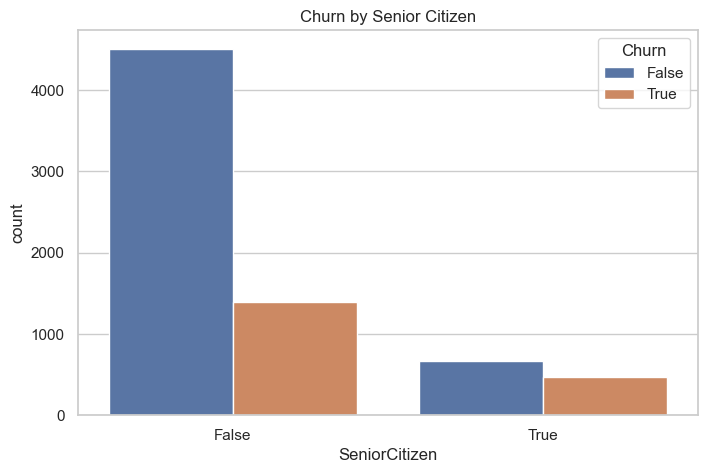

,No Churn (%),Churn (%)
SeniorCitizen,,
True,58.32,41.68
False,76.39,23.61


In [19]:
# ================== Churn vs SeniorCitizen ==================
# Apakah pelanggan lansia memiliki risiko churn lebih tinggi?

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="SeniorCitizen", hue="Churn")
plt.title("Churn by Senior Citizen")
plt.show()

# Crosstab persentase churn per status senior citizen
senior_churn = pd.crosstab(df["SeniorCitizen"], df["Churn"], normalize="index") * 100
senior_churn.columns = ["No Churn (%)", "Churn (%)"]
senior_churn = senior_churn.sort_values(by="Churn (%)", ascending=False).round(2)
senior_churn

**Insight**

Analisis menunjukkan bahwa pelanggan Senior Citizen memiliki tingkat churn yang lebih tinggi dibandingkan pelanggan non-lansia. Sekitar 41.68% pelanggan lansia melakukan churn, sedangkan pada pelanggan non-lansia tingkat churn hanya sekitar 23.61%. Hal ini mengindikasikan bahwa kelompok pelanggan lansia cenderung lebih rentan untuk berhenti berlangganan, sehingga dapat menjadi segmen yang perlu mendapat perhatian khusus dalam strategi retensi pelanggan.

# Correlation Matrix

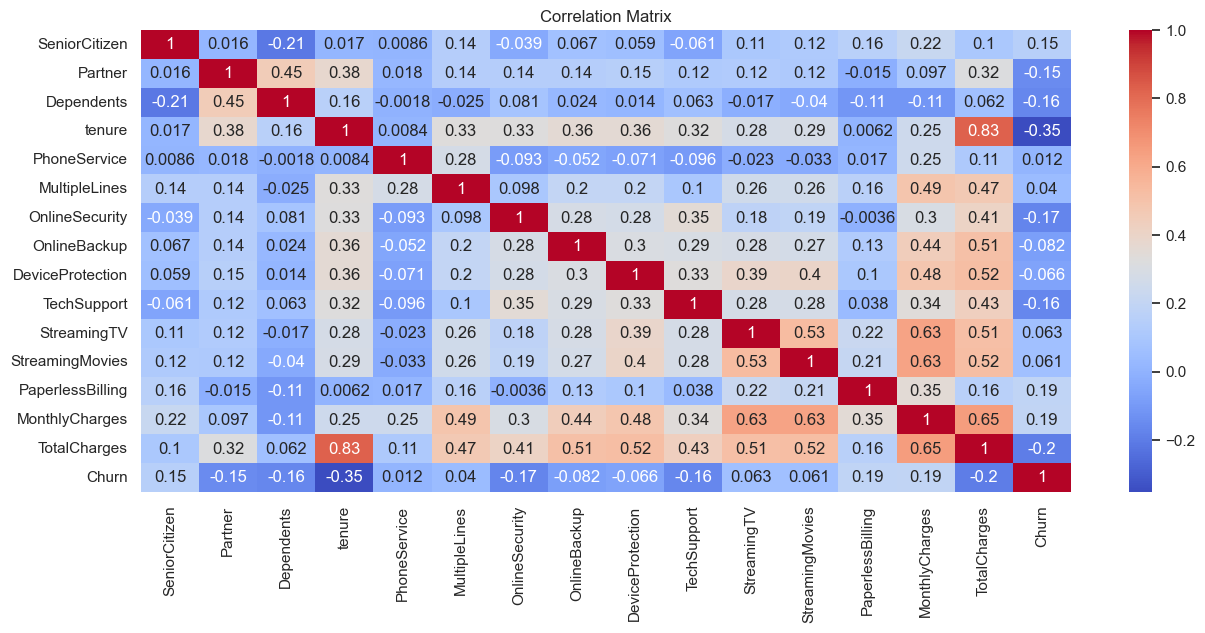

In [20]:
plt.figure(figsize=(15, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


## Insight Correlation Matrix

Analisis correlation matrix digunakan untuk melihat hubungan antar variabel numerik dan mengidentifikasi faktor yang berkaitan dengan churn pelanggan.

### 1. Tenure dan Churn

Variabel **tenure** memiliki korelasi negatif paling kuat terhadap churn (**-0.35**). Hal ini menunjukkan bahwa pelanggan dengan masa berlangganan yang lebih lama cenderung lebih loyal, sedangkan pelanggan baru memiliki risiko churn yang lebih tinggi.

### 2. Monthly Charges dan Churn

Variabel **MonthlyCharges** memiliki korelasi positif kecil dengan churn (**0.19**). Ini mengindikasikan bahwa pelanggan dengan biaya bulanan lebih tinggi sedikit lebih rentan untuk churn.

### 3. Total Charges dan Churn

**TotalCharges** memiliki korelasi negatif dengan churn (**-0.20**), menunjukkan bahwa pelanggan dengan total pengeluaran yang lebih besar cenderung lebih jarang berhenti berlangganan.

### 4. Tenure dan Total Charges

Terdapat korelasi sangat kuat antara **tenure dan TotalCharges (0.83)**, yang menunjukkan bahwa pelanggan dengan masa berlangganan lebih lama memberikan kontribusi revenue yang lebih besar.

### 5. Pola Bundling Layanan

Beberapa layanan seperti **StreamingTV dan StreamingMovies (0.53)** serta layanan tambahan lainnya menunjukkan korelasi positif, yang mengindikasikan adanya perilaku pembelian layanan secara bundling.

### Key Takeaway

Variabel yang paling berkaitan dengan churn adalah **tenure, MonthlyCharges, dan TotalCharges**, yang menunjukkan bahwa lama berlangganan dan biaya layanan merupakan faktor penting dalam risiko churn pelanggan.


# Revenue Impact Insight

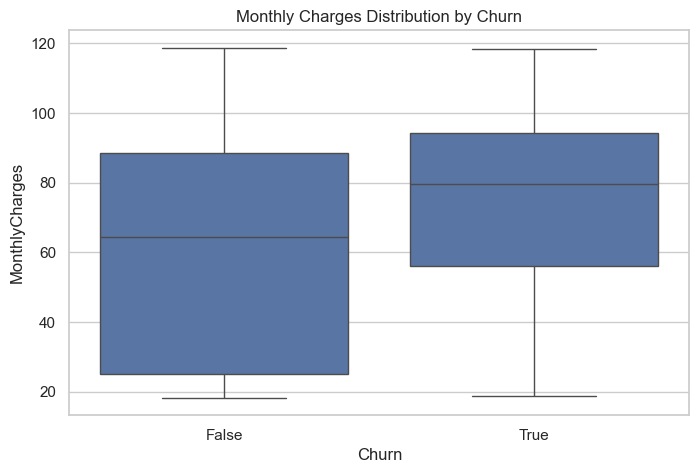

,Churn,MonthlyCharges
0,True,74.44
1,False,61.27


In [21]:
# ========== Average Monthly Charges Berdasarkan Status Churn ==========
# Average Monthly Charges Berdasarkan Status Churn
# - Apakah customer yang churn membayar lebih mahal?

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges Distribution by Churn")
plt.show()

# Hitung rata-rata monthly charges per kelompok churn
avg_monthly_by_churn = (
    df.groupby("Churn")["MonthlyCharges"]
      .mean()
      .sort_values(ascending=False)
      .round(2)
      .reset_index()
)

avg_monthly_by_churn

**Insight**

Pelanggan yang churn memiliki rata-rata MonthlyCharges lebih tinggi (74.44) dibanding non-churn (61.27). Hal ini mengindikasikan bahwa pelanggan dengan biaya bulanan lebih tinggi memiliki kecenderungan churn yang lebih besar, sehingga segmen ini dapat menjadi salah satu fokus dalam strategi retensi.

In [22]:
# =============== Total Revenue Lost Akibat Churn ===============
# - Berapa total revenue yang hilang akibat churn?

# Filter customer yang churn
churned_customers = df[df["Churn"] == 1]

# Total revenue lost
total_revenue_lost = churned_customers["TotalCharges"].sum()
print(f"Total Revenue Lost due to Churn: {total_revenue_lost:,.2f}")

# Total revenue lost percentage
total_revenue = df["TotalCharges"].sum()
revenue_loss_pct = (total_revenue_lost / total_revenue) * 100
print(f"Revenue Loss Percentage: {revenue_loss_pct:.2f}%")

Total Revenue Lost due to Churn: 2,862,926.90
Revenue Loss Percentage: 17.83%


**Insight**

Perusahaan mengalami potensi kehilangan pendapatan sebesar 2,862,926.90, yang setara dengan 17.83% dari total revenue, akibat churn. Angka ini menunjukkan bahwa dampak churn terhadap kinerja finansial sangat signifikan, sehingga penerapan strategi retention yang efektif berpotensi memberikan dampak finansial yang signifikan bagi perusahaan.

In [23]:
# ============ Total Revenue Berdasarkan Contract Type ===============
# - Contract mana yang menghasilkan revenue terbesar?

revenue_contract = (
    df.groupby("Contract")["TotalCharges"]
    .sum()
    .sort_values(ascending=False)
    .round(2)
)

print("total revenue by contract type:")
print(revenue_contract)

total revenue by contract type:
Contract
two year          6283253.7
month-to-month    5305861.5
one year          4467053.5
Name: TotalCharges, dtype: float64


**Insight**

Kontrak dua tahun menghasilkan revenue terbesar, disusul oleh kontrak month-to-month, dan kemudian kontrak satu tahun. Hal ini menunjukkan bahwa pelanggan dengan komitmen jangka panjang memberikan kontribusi pendapatan yang lebih stabil dan signifikan.

In [24]:
# ============= Revenue Lost Berdasarkan Contract Type ==============
# - Contract mana yang paling banyak menyebabkan revenue loss?

lost_by_contract = (
    df[df["Churn"] == 1]
    .groupby("Contract")["TotalCharges"]
    .sum()
    .sort_values(ascending=False)
)

print("revenue lost due to churn by contract type:")
print(lost_by_contract.round(2))

revenue lost due to churn by contract type:
Contract
month-to-month    1927182.25
one year           674991.20
two year           260753.45
Name: TotalCharges, dtype: float64


**Insight**

Pelanggan dengan kontrak month-to-month menyumbang kehilangan revenue terbesar akibat churn. Ini menunjukkan bahwa pelanggan tanpa komitmen jangka panjang memiliki risiko churn lebih tinggi, sehingga perlu strategi retensi khusus seperti penawaran harga lebih kompetitif atau insentif untuk beralih ke kontrak jangka panjang.

In [25]:
# ============ Churn Revenue Rate per Contract Type ==============
# - Berapa persentase revenue yang hilang di tiap contract?

# Total revenue per contract
revenue_contract = (
    df.groupby("Contract")["TotalCharges"]
    .sum()
    .reset_index()
    .rename(columns={"TotalCharges": "Total_Revenue"})
)

# Revenue lost (churn = 1)
lost_by_contract = (
    df[df["Churn"] == 1]
    .groupby("Contract")["TotalCharges"]
    .sum()
    .reset_index()
    .rename(columns={"TotalCharges": "Revenue_Lost"})
)

# Merge
revenue_summary = revenue_contract.merge(
    lost_by_contract,
    on="Contract",
    how="left"
)

revenue_summary["Revenue_Lost"] = revenue_summary["Revenue_Lost"].fillna(0)

# Tambahkan churn revenue rate
revenue_summary["Lost_%"] = (
    revenue_summary["Revenue_Lost"] /
    revenue_summary["Total_Revenue"] * 100
).round(2)

# Format angka biar enak dibaca
revenue_summary["Total_Revenue"] = revenue_summary["Total_Revenue"].round(2)
revenue_summary["Revenue_Lost"] = revenue_summary["Revenue_Lost"].round(2)

print(revenue_summary.sort_values(by="Total_Revenue", ascending=False))


         Contract  Total_Revenue  Revenue_Lost  Lost_%
2        two year      6283253.7     260753.45    4.15
0  month-to-month      5305861.5    1927182.25   36.32
1        one year      4467053.5     674991.20   15.11


**Insight**

Kontrak month-to-month memiliki tingkat churn tertinggi (36,32%) dibandingkan one-year (15,11%) dan two-year (4,15%), sehingga menjadi sumber utama potensi kehilangan revenue. Hal ini menunjukkan bahwa pelanggan tanpa komitmen jangka panjang memiliki risiko churn lebih tinggi. Strategi bisnis yang dapat dilakukan meliputi mendorong upsell ke kontrak satu atau dua tahun, menawarkan insentif atau diskon konversi kontrak, serta menjalankan early retention campaign khusus bagi pelanggan month-to-month.